In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.optimize import curve_fit

In [4]:
df = pd.read_csv('Nat_Gas.csv')
df['Dates'] = pd.to_datetime(df['Dates'])

/var/folders/7s/z384wkj17fv54g1fgd2fklxr0000gn/T/ipykernel_48986/4157460294.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


<Axes: xlabel='Dates', ylabel='Prices'>

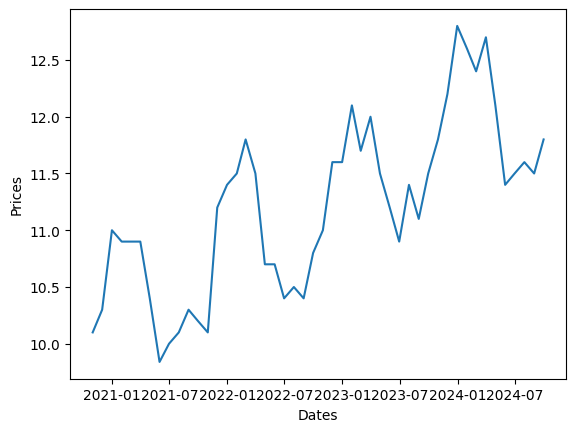

In [5]:
sns.lineplot(df, x='Dates', y='Prices')

From this graph, we can see that gas prices seem to have a yearly cycle, which is gradually increasing with time. This looks like it would be best modelled by a sine curve, with a linear function to account for the increase over time. 

So the function I will use will be 
y = ax + b + c sin(dx + e)
where y is the price and x is the number of months since the start of the data (Oct 2020)

In [6]:
df['x_col'] = df.index
xdata = df['x_col'].values
ydata = df['Prices'].values

In [7]:
def model(x, a, b, c, d, e):
    return a*x + b + c*np.sin(2* np.pi * (d*x + e))
guess = [1,1,1,1,0]
param, cov = curve_fit(model, xdata, ydata)
a, b, c, d, e = param
print(a, b, c, d ,e)

0.04555591881730944 10.137736410054659 -0.6931020368361913 0.9161982123646546 2.019639446770258


In [8]:
def estimate(months):
    price = a*months + b + c*np.sin(d*months + e)

df['Estimate'] = model(xdata, *param)
df

,Dates,Prices,x_col,Estimate
0,2020-10-31,10.10,0,10.052426
1,2020-11-30,10.30,1,10.455205
2,2020-12-31,11.00,2,10.784323
3,2021-01-31,10.90,3,10.962962
4,2021-02-28,10.90,4,10.955072
5,2021-03-31,10.90,5,10.775129
6,2021-04-30,10.40,6,10.484223
7,2021-05-31,9.84,7,10.173499
8,2021-06-30,10.00,8,9.939476
9,2021-07-31,10.10,9,9.857890


<Axes: xlabel='Dates', ylabel='Prices'>

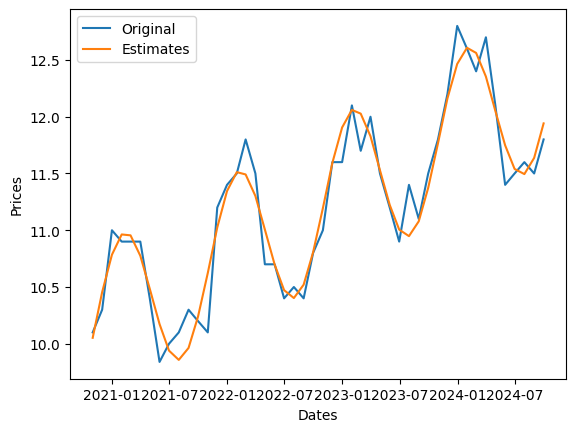

In [9]:
sns.lineplot(data=df, x='Dates', y='Prices', label='Original')
sns.lineplot(data=df, x='Dates', y='Estimate', label='Estimates')

And we can plot what the graph would look like if we extrapolate an extra year. 

<Axes: xlabel='Months since Oct 2020', ylabel='Estimated Price'>

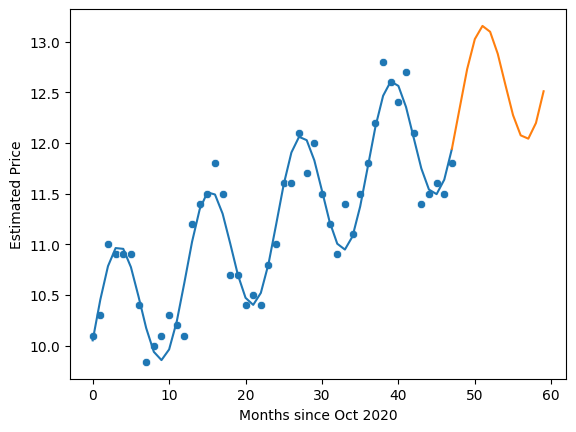

In [10]:
x_new = np.arange(0,60)
y_new = model(x_new, *param)

df_estimates = pd.DataFrame({'Months since Oct 2020':x_new, 'Estimated Price': y_new})
df_inter = df_estimates[df_estimates['Months since Oct 2020'] <= 47]
df_extra = df_estimates[df_estimates['Months since Oct 2020'] >= 47]
sns.lineplot(df_inter, x = 'Months since Oct 2020', y = 'Estimated Price')
sns.lineplot(df_extra, x = 'Months since Oct 2020', y = 'Estimated Price')
sns.scatterplot(data = df, x = 'x_col', y='Prices')

In [11]:
def generate_estimate(date):
    '''This takes in a date and generates a price estimate'''
    reference_date = pd.to_datetime("2020-10-01")
    input_date = pd.to_datetime(date)
    months_since = (input_date.year - reference_date.year) * 12 + input_date.month - reference_date.month
    return model(months_since, *param)

print(generate_estimate('1/3/2022'))
print(generate_estimate('1/4/2025'))

11.512001969605986
13.153943002689317


TASK 2:

In [30]:
INJECTION = ['2022-03-01'] 
WITHDRAWAL = ['2022-10-01']
RATE = 1000 #$/month
MAXVOL = 500 #MMBTu
STORAGE = 0.1 #$/month

In [31]:
dates = []
for date in INJECTION:
    dates.append((pd.to_datetime(date),generate_estimate(date) , 'I'))
for date in WITHDRAWAL:
    dates.append((pd.to_datetime(date), generate_estimate(date), 'W'))
dates = sorted(dates, key = lambda date: date[0])

In [32]:
def calculate_profit(dates, injection_rate, max_storage, storage_cost, final_date):
    profit = 0
    volume = 0
    START_DATE = pd.to_datetime("2020-10-01")
    DAYS_IN_MONTH = 30.5
    prev_date = START_DATE
    for date_tuple in dates:
        date, cost, iORw = date_tuple
        #calculates storage cost from previous date in dates
        profit -= volume * storage_cost * (date.to_period("M") - prev_date.to_period("M")).n
        if iORw == "I":
            inject_volume = min(max_storage - volume, injection_rate)
            profit -= inject_volume * cost
            volume += inject_volume
        else:
            withdrawal_volume = min(injection_rate, volume)
            profit += withdrawal_volume * cost
            volume -= withdrawal_volume
        prev_date = date
    profit -= volume * storage_cost * (final_date.to_period("M") - prev_date.to_period("M")).n
    return profit

In [33]:
print(calculate_profit(dates, RATE, MAXVOL, STORAGE, pd.to_datetime("2025-01-01")))

-403.6356872870765
